# Sales Data Analysis: Who Spends the Most?

Exploratory data analysis (EDA) of customer sales data using **Python, pandas, seaborn and matplotlib**.

**Goal:** find out which customer groups (gender, age, marital status, state, occupation) and which product categories drive the most spending.

**Dataset:** `data/sales_data.csv` has 11,251 order records with customer demographics, location, product category, number of orders and amount (₹).

**Code structure:** the core logic (loading, cleaning, plotting and summary functions) lives in [`src/analysis.py`](src/analysis.py). This notebook imports it and focuses on the analysis and the story.

**Workflow:** 1. Data cleaning → 2. Data visualization → 3. Summary → 4. Conclusion

In [1]:
from src.analysis import load_data, clean_data, spend, summary

## 1. Data Cleaning

In [2]:
raw = load_data()
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (11251, 15)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


Checking what needs cleaning:

In [3]:
print("Duplicate rows:", raw.duplicated().sum())
print("Completely empty columns:", list(raw.columns[raw.isnull().all()]))
print("Missing Amount values (after removing duplicates):", raw.drop_duplicates()["Amount"].isnull().sum())

Duplicate rows: 8
Completely empty columns: ['Status', 'unnamed1']
Missing Amount values (after removing duplicates): 12


`clean_data()` removes the duplicates, drops the empty columns, removes rows with missing `Amount`, and makes `Gender` (F/M) and `Marital_Status` (0/1) readable.

In [4]:
df = clean_data(raw)
print("Clean shape:", df.shape)
df.head()

Clean shape: (11231, 13)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,Female,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,Female,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,Female,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,Male,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,Male,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


In [5]:
df["Occupation"].unique()

<StringArray>
[     'Healthcare',            'Govt',      'Automobile',    'Construction',
 'Food Processing',          'Lawyer',           'Media',         'Banking',
          'Retail',       'IT Sector',        'Aviation',     'Hospitality',
     'Agriculture',         'Textile',        'Chemical']
Length: 15, dtype: str

**Cleaning summary:** removed 8 duplicate rows, dropped the 2 completely empty columns (`Status`, `unnamed1`), removed 12 rows with missing `Amount`, and made `Gender` and `Marital_Status` readable. Final dataset: **11,231 rows × 13 columns**.

## 2. Data Visualization

`spend(df, column)` prints the highest and lowest spending group and draws four charts: order count, spend share (pie or bar), amount distribution (box plot) and highest vs lowest group.

### Gender

Top Gender by spend: Female  (₹ 74,307,682, 70.0% of total)
Lowest Gender by spend: Male  (₹ 31,871,146, 30.0% of total)


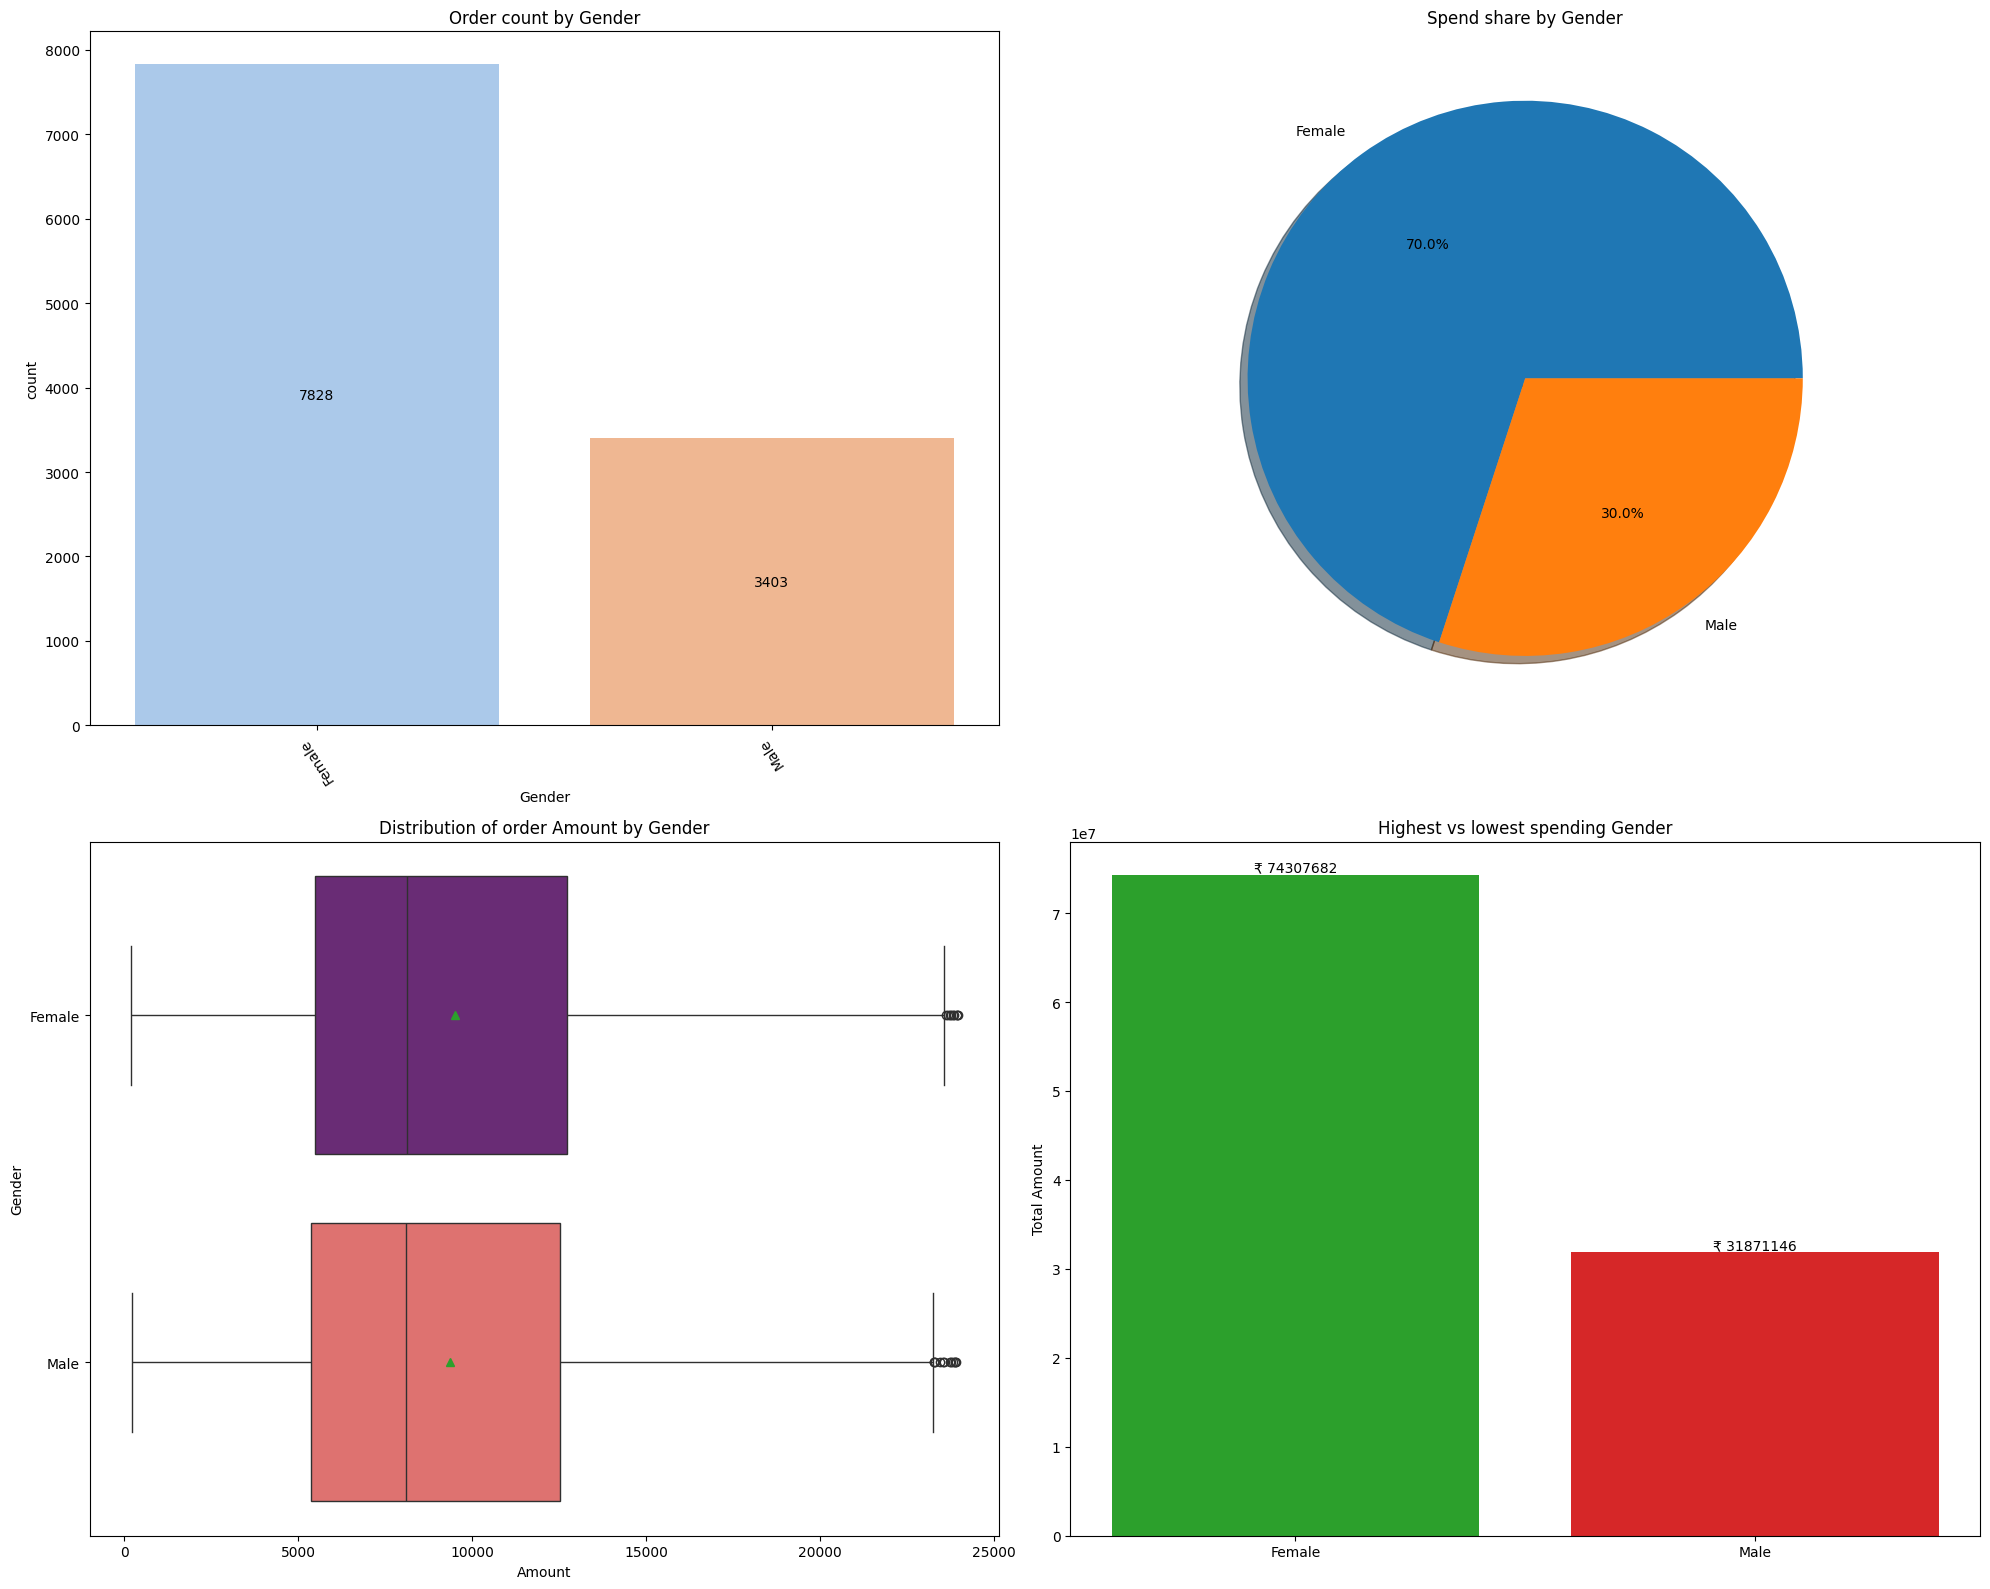

In [6]:
spend(df, "Gender")

### Age Group

Top Age Group by spend: 26-35  (₹ 42,581,769, 40.1% of total)
Lowest Age Group by spend: 0-17  (₹ 2,699,653, 2.5% of total)


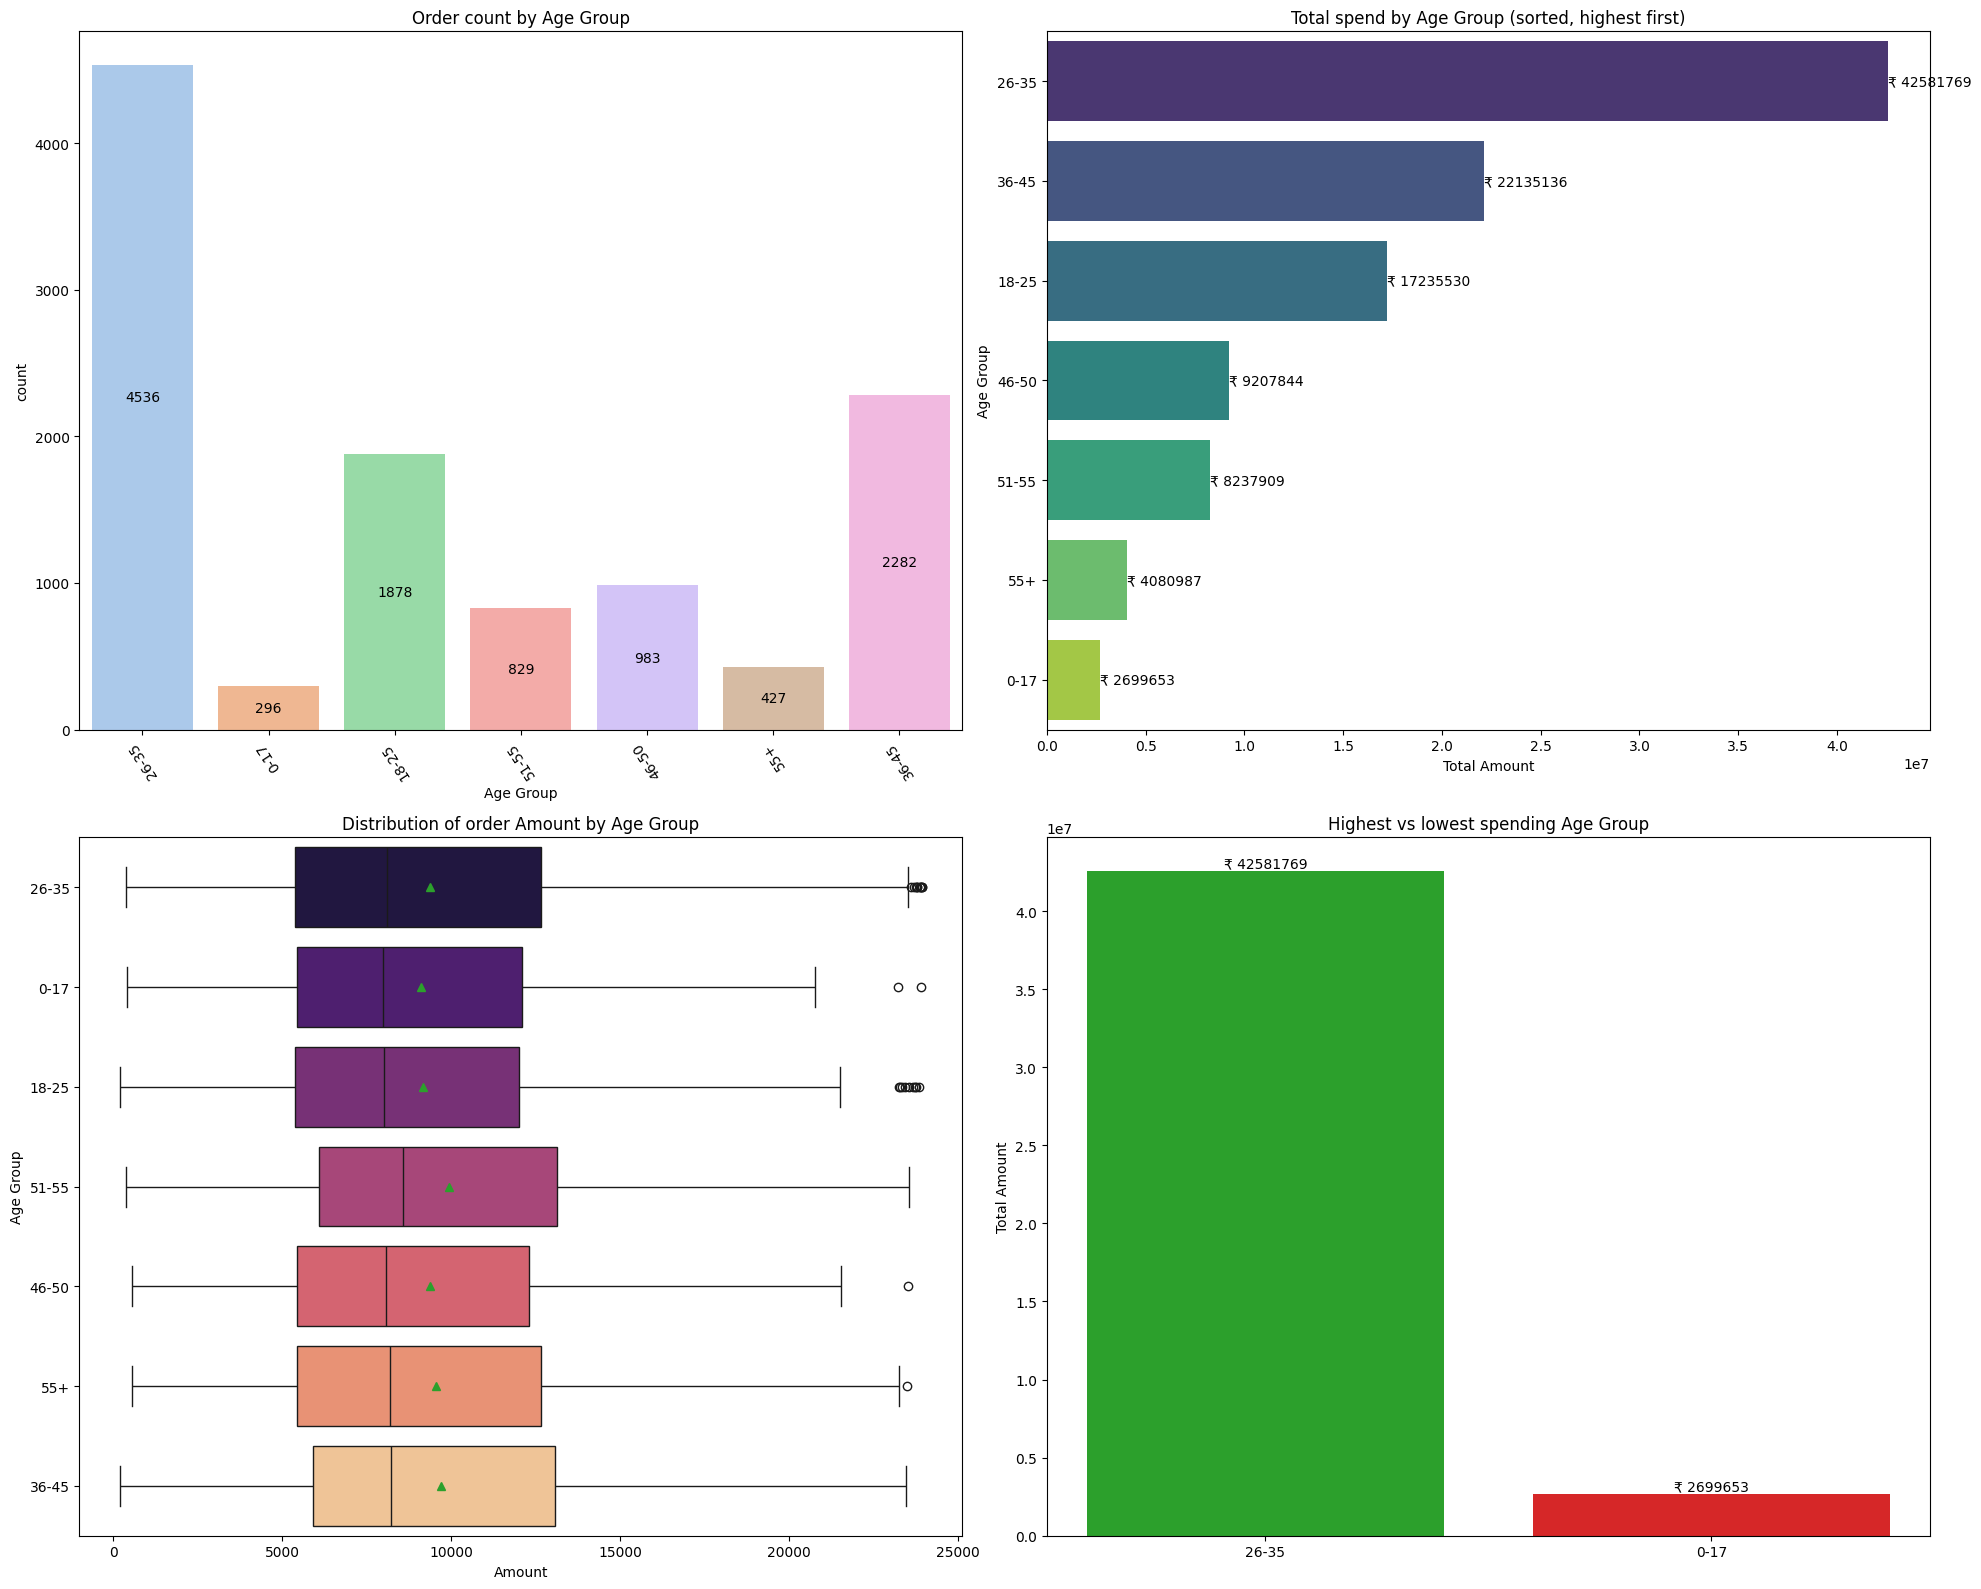

In [7]:
spend(df, "Age Group")

### State

Top State by spend: Uttar Pradesh  (₹ 19,346,055, 18.2% of total)
Lowest State by spend: Telangana  (₹ 1,151,490, 1.1% of total)


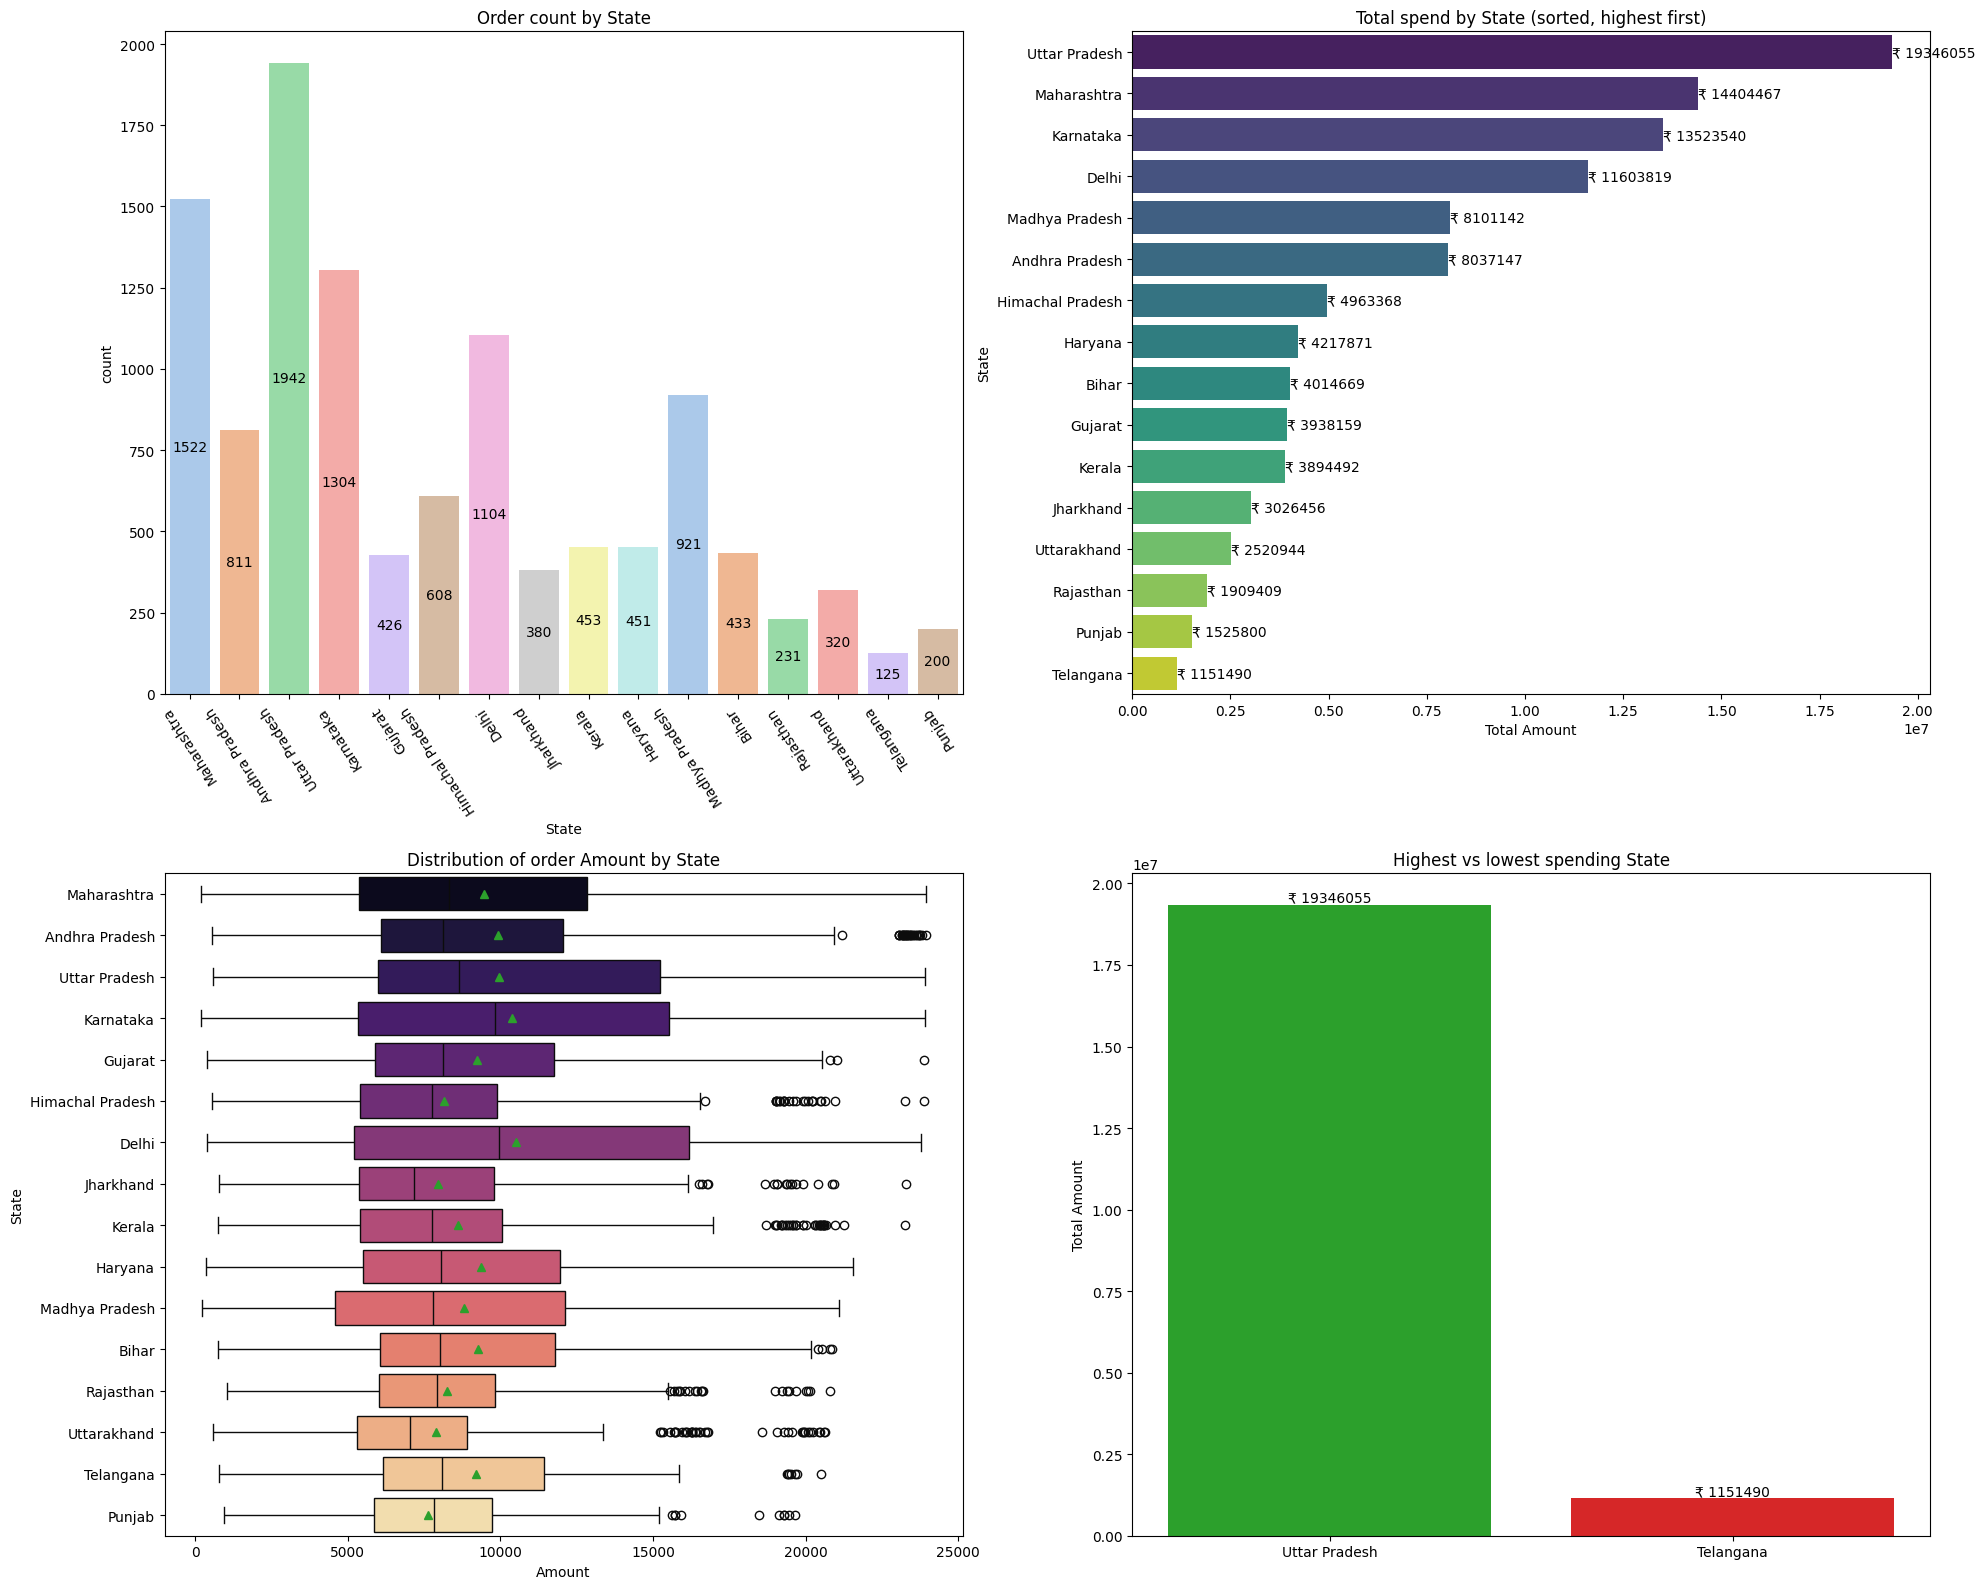

In [8]:
spend(df, "State")

### Occupation

Top Occupation by spend: IT Sector  (₹ 14,741,862, 13.9% of total)
Lowest Occupation by spend: Agriculture  (₹ 2,584,999, 2.4% of total)


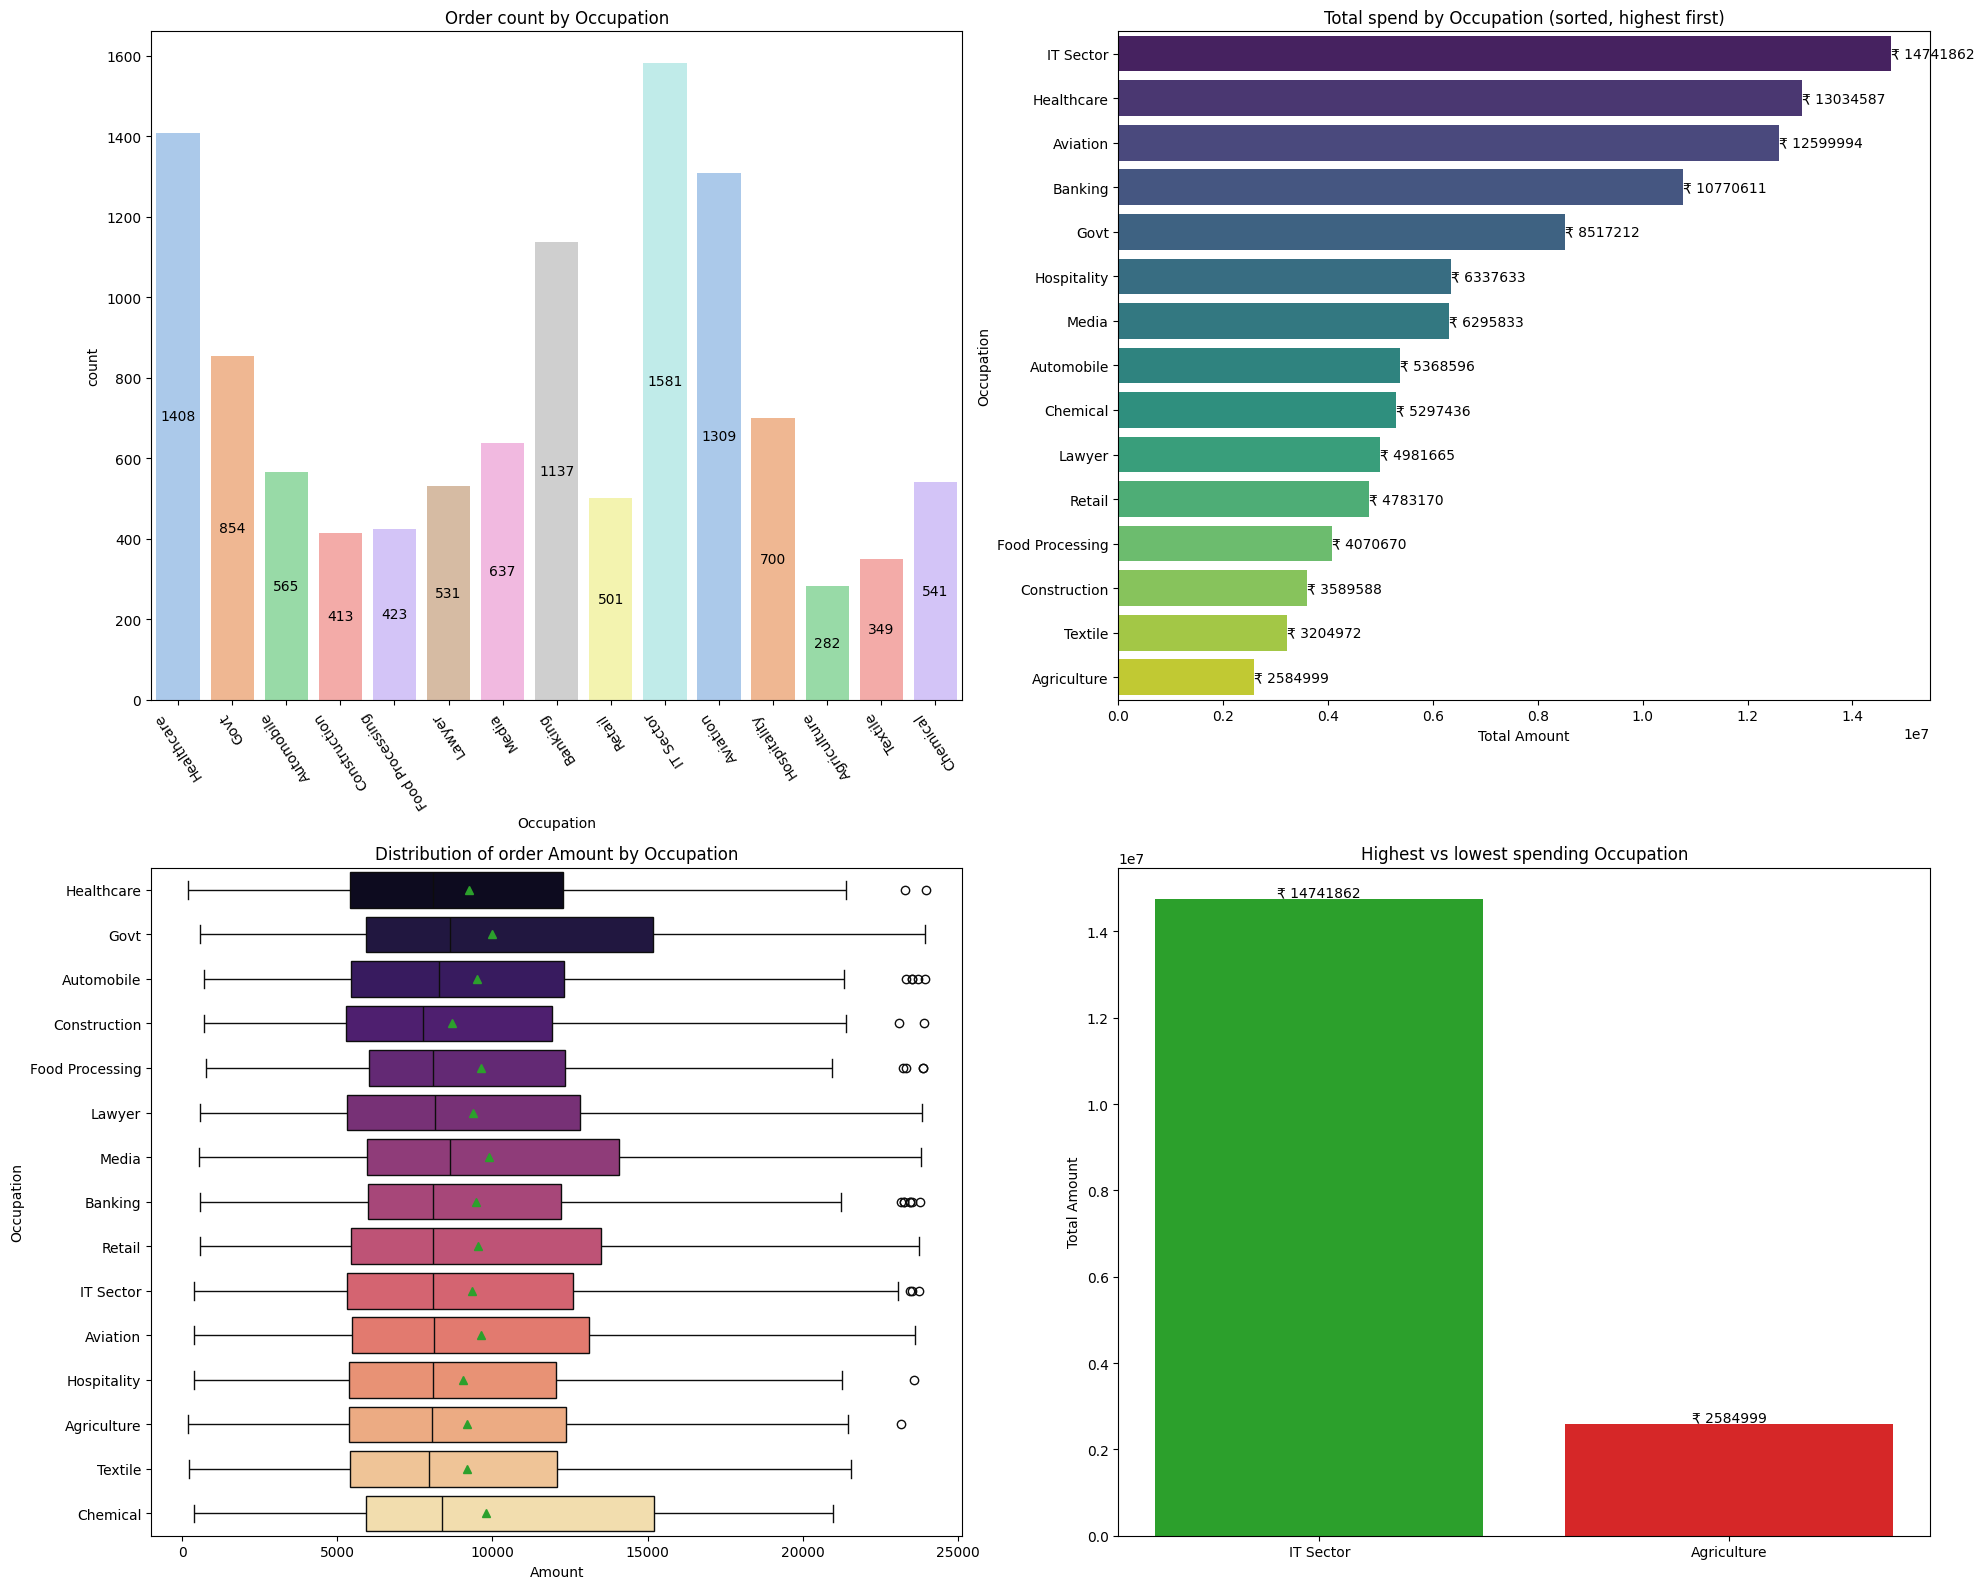

In [9]:
spend(df, "Occupation")

### Product Category

Top Product_Category by spend: Food  (₹ 33,933,884, 32.0% of total)
Lowest Product_Category by spend: Office  (₹ 81,936, 0.1% of total)


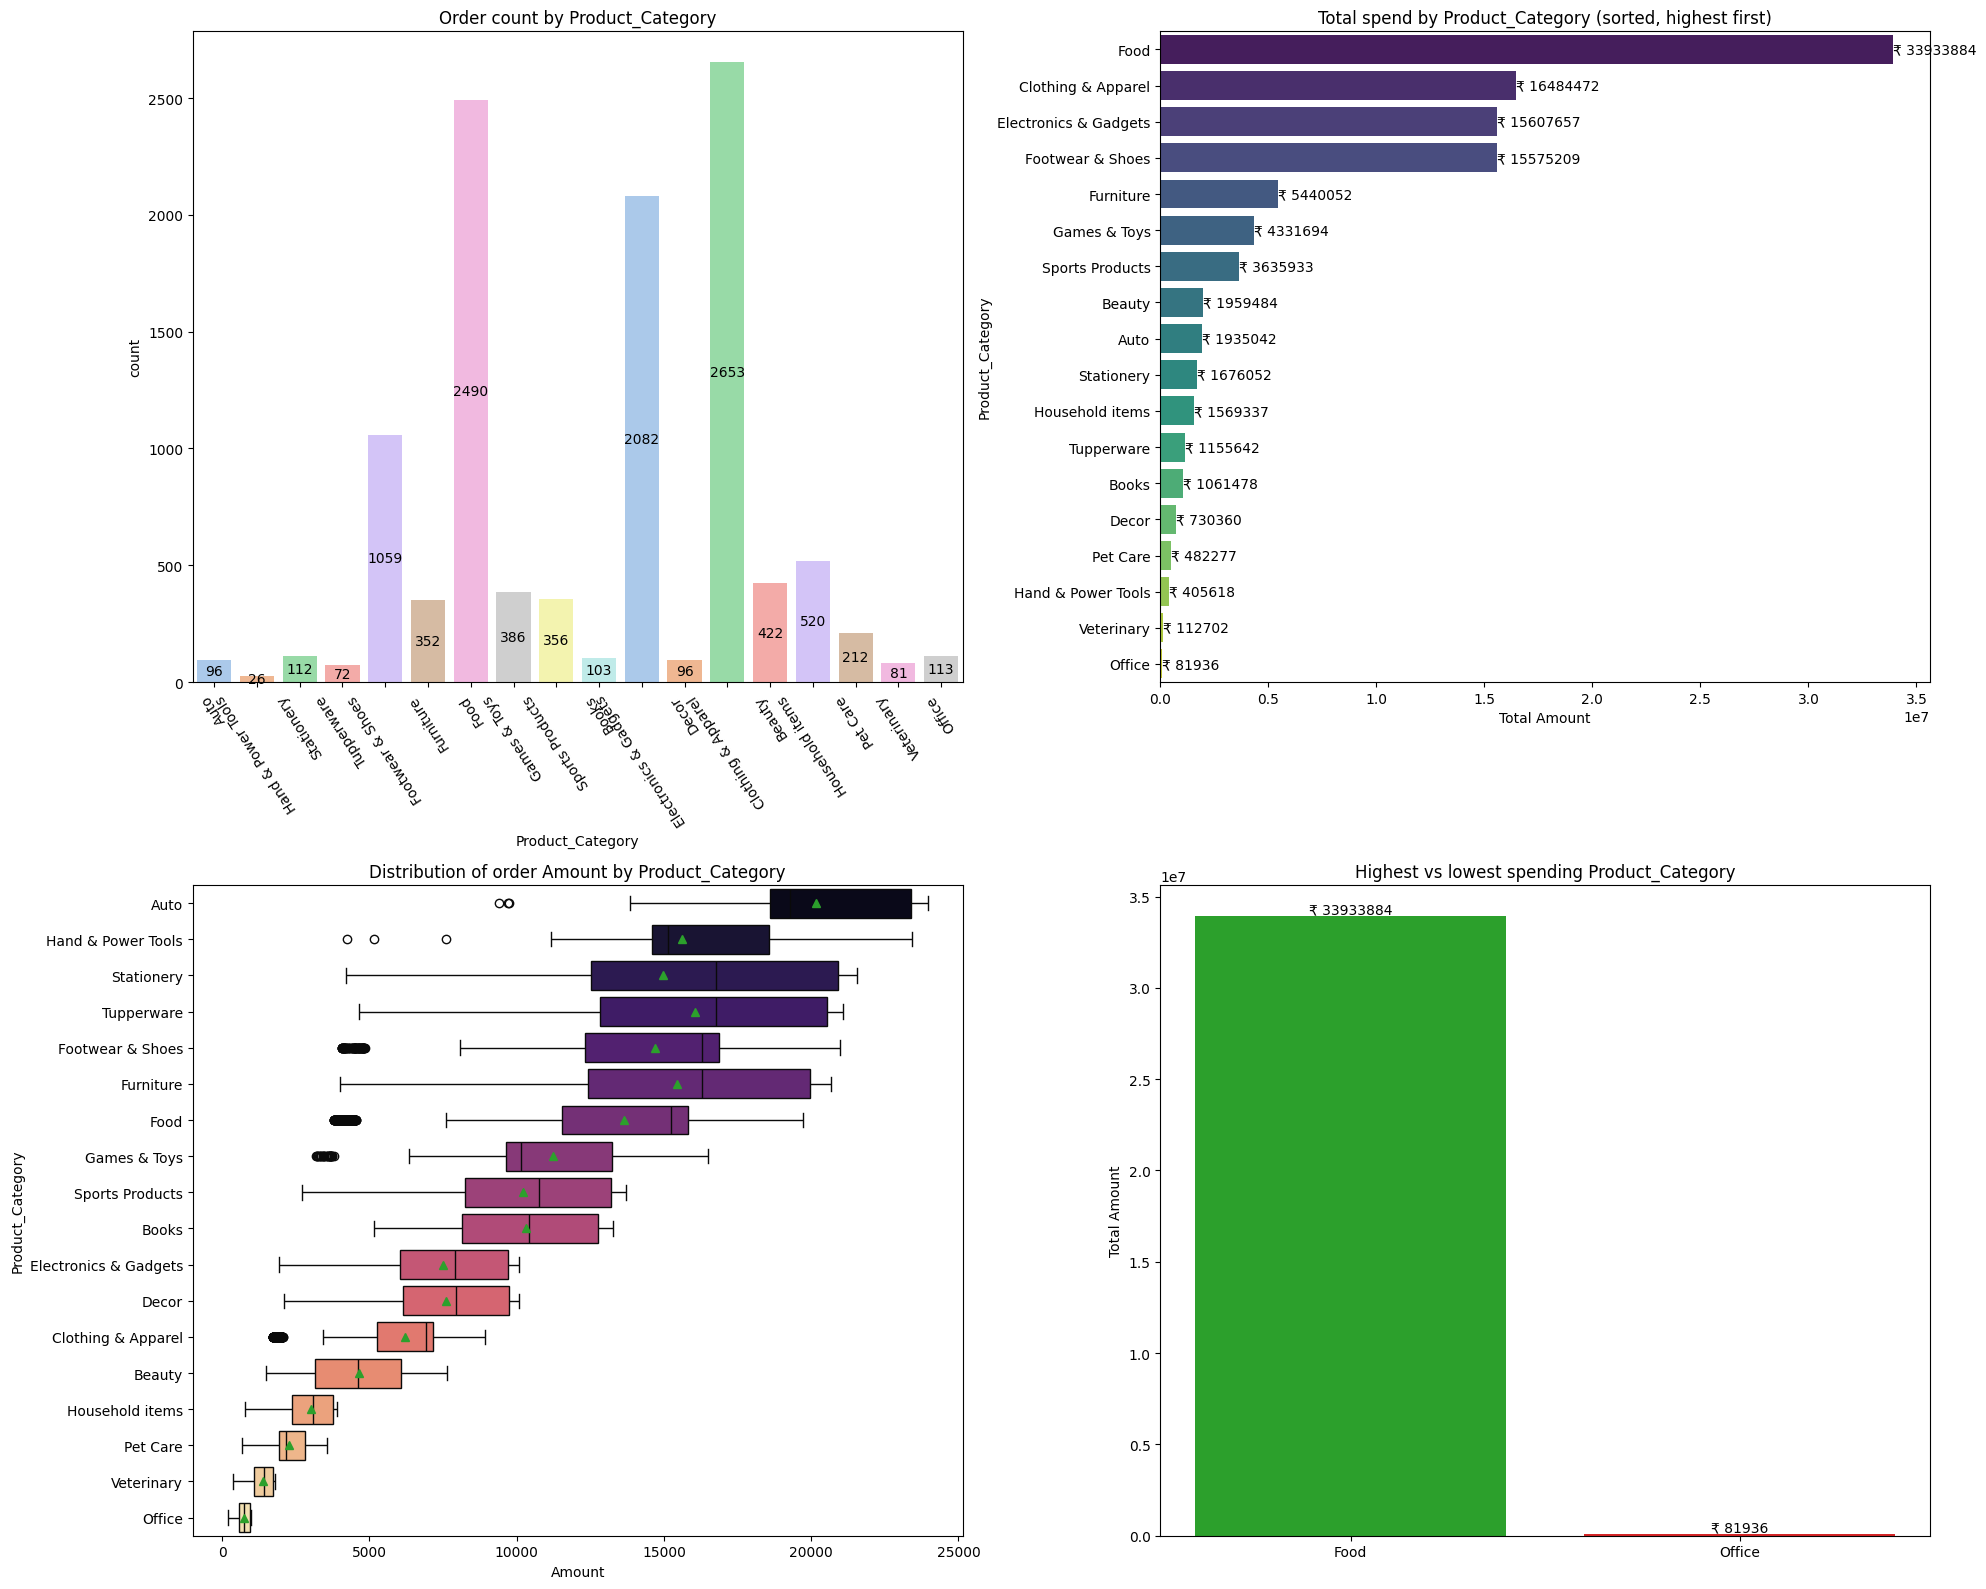

In [10]:
spend(df, "Product_Category")

### Marital Status

Top Marital_Status by spend: Single  (₹ 62,098,736, 58.5% of total)
Lowest Marital_Status by spend: Married  (₹ 44,080,092, 41.5% of total)


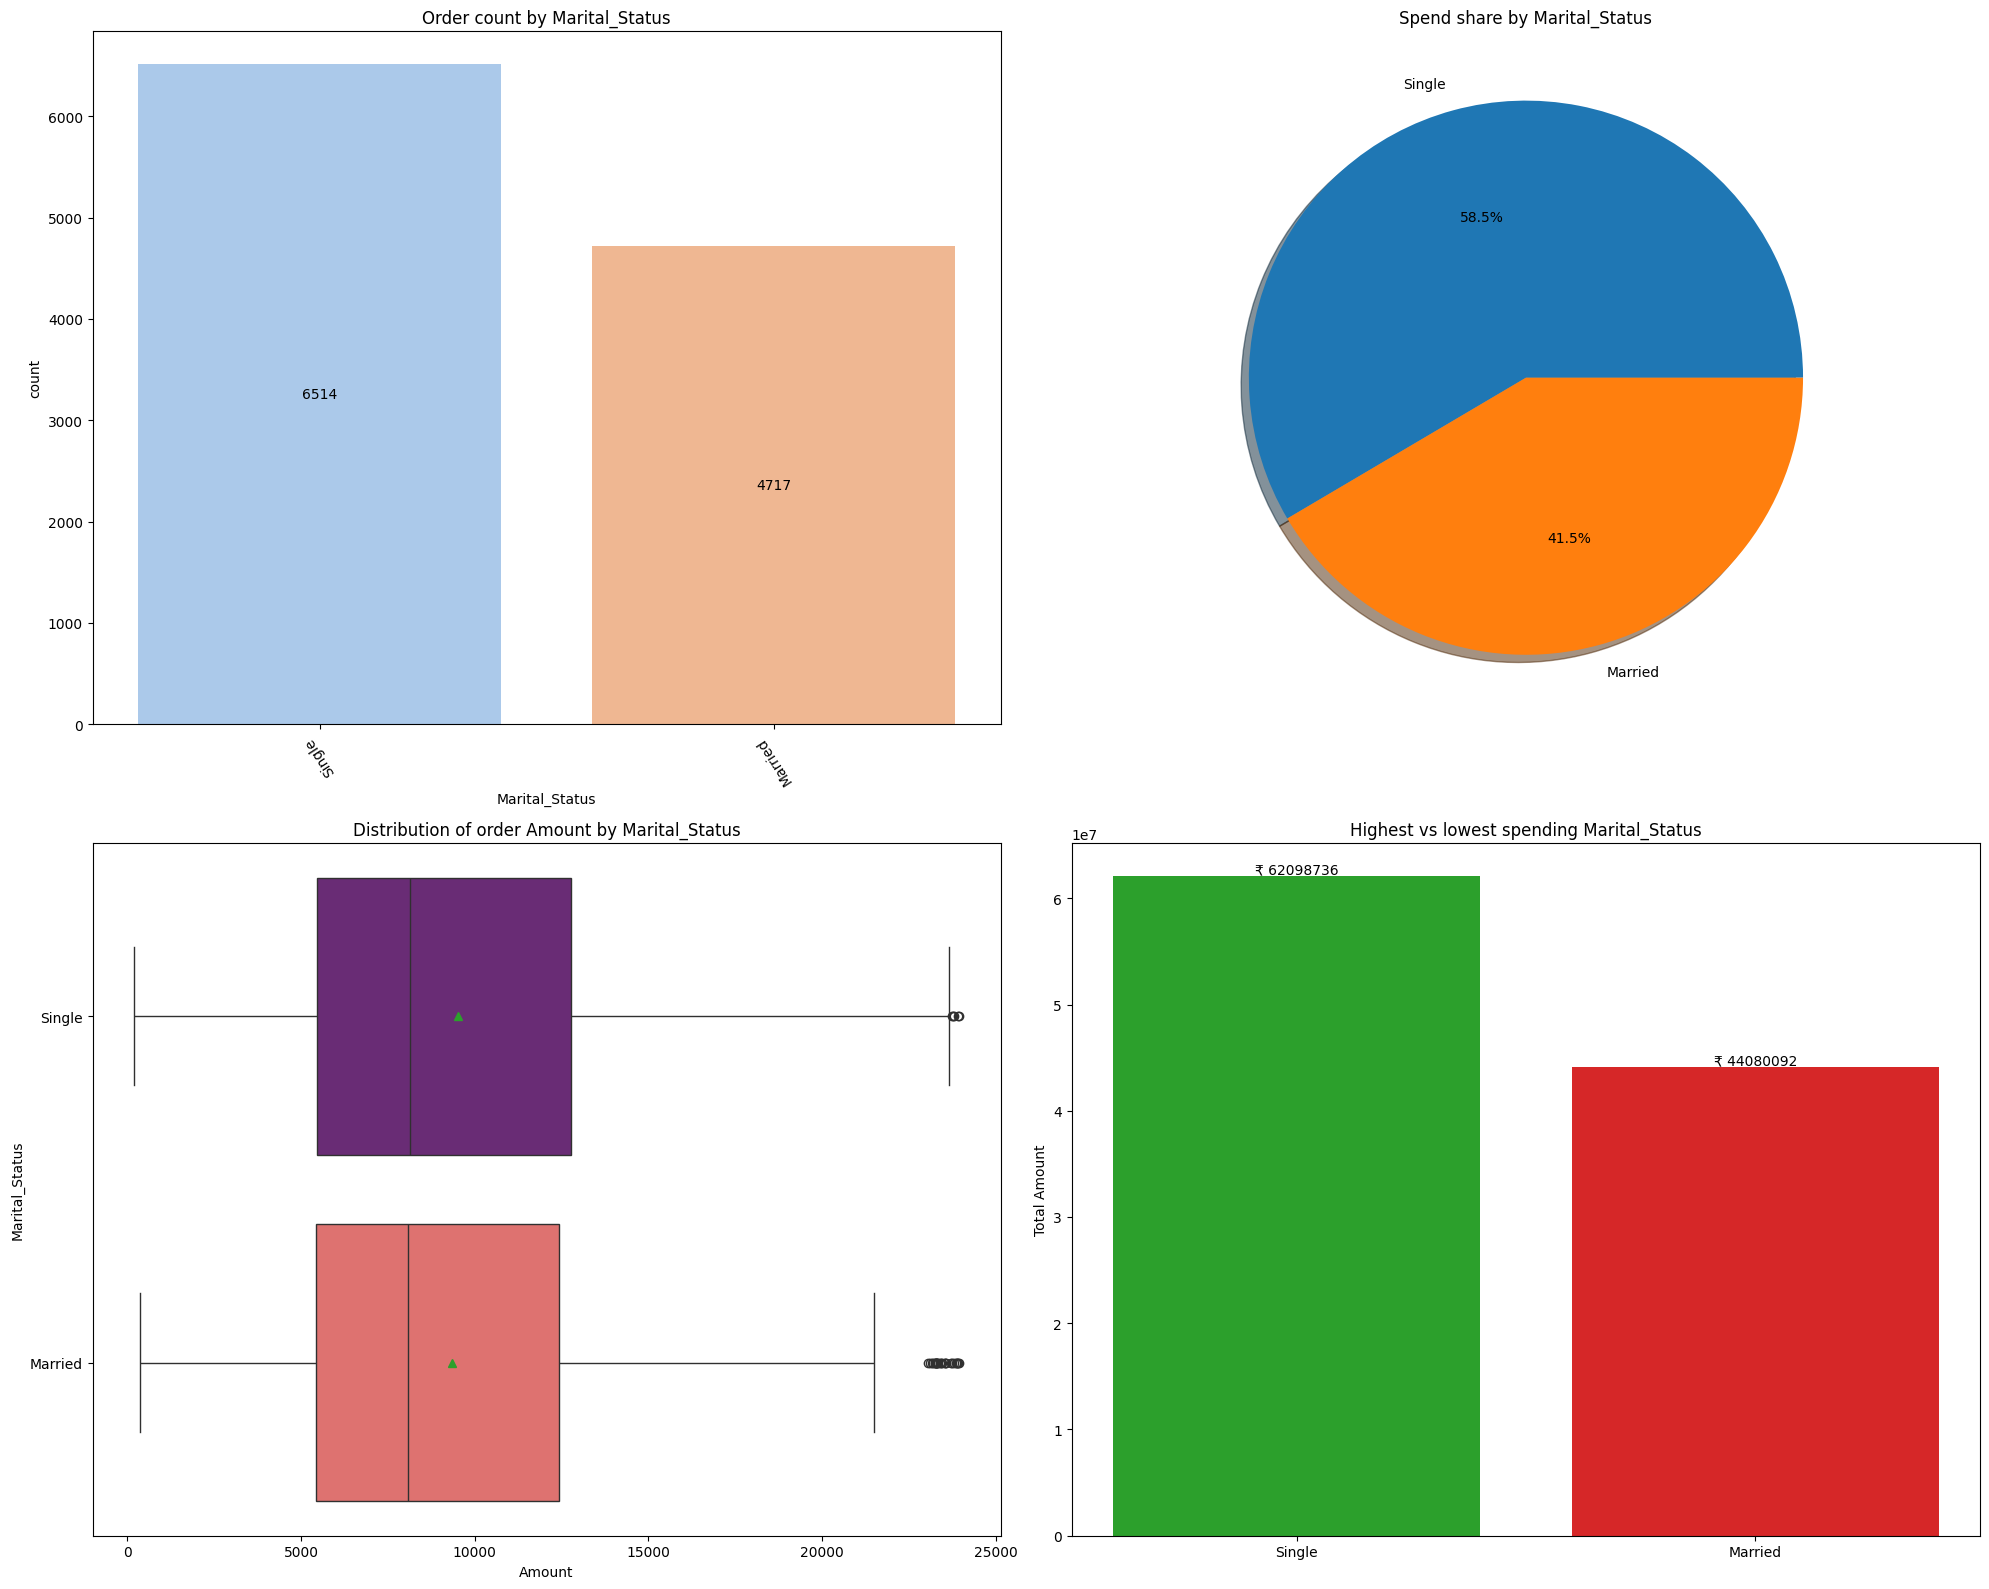

In [11]:
spend(df, "Marital_Status")

## 3. Summary

Highest and lowest spending group in every category.

In [12]:
summary(df)

,Category,max spend category,max spend amount,min spend category,min spend amount
0,Gender,Female,"₹ 74,307,682",Male,"₹ 31,871,146"
1,State,Uttar Pradesh,"₹ 19,346,055",Telangana,"₹ 1,151,490"
2,Occupation,IT Sector,"₹ 14,741,862",Agriculture,"₹ 2,584,999"
3,Age Group,26-35,"₹ 42,581,769",0-17,"₹ 2,699,653"
4,Marital_Status,Single,"₹ 62,098,736",Married,"₹ 44,080,092"
5,Product_Category,Food,"₹ 33,933,884",Office,"₹ 81,936"


## 4. Conclusion

- **Who spends the most:** single women aged 26-35 (women 70.0% of total spend, ages 26-35 40.1%, single customers 58.5%).
- **Where:** Uttar Pradesh (18.2%), Maharashtra (13.6%) and Karnataka (12.7%) together make up about 44.5% of total spend.
- **Occupation:** IT Sector (13.9%), Healthcare (12.3%) and Aviation (11.9%) lead.
- **What they buy:** Food (32.0%), then Clothing & Apparel (15.5%), Electronics & Gadgets (14.7%) and Footwear & Shoes (14.7%).
- **Note:** women lead because they place about 70% of the orders, not because their orders are bigger. The average order amount is almost the same (₹9,493 for women vs ₹9,366 for men).

**Suggestion:** focus marketing on women aged 26-35 in the top three states, with Food, Apparel, Electronics and Footwear offers.